In [ ]:
!pip install boto3

In [ ]:
import boto3
import pandas as pd
from io import StringIO

# AWSのアクセスキーとシークレットキーを設定

# S3クライアントを作成
s3_client = boto3.client(
    "s3",
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
)

# S3からCSVファイルを読み込む
response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
csv_content = response["Body"].read().decode("utf-8")

# CSVコンテンツをDataFrameに変換
data = pd.read_csv(StringIO(csv_content))

# データの表示
print(data.head())

In [ ]:
# データの処理（例: 新しい列を追加）
data["new_column"] = data["existing_column"] * 2

# 変更したデータをS3にアップロード
csv_buffer = StringIO()
data.to_csv(csv_buffer, index=False)

s3_client.put_object(
    Bucket=bucket_name, Key="path/to/your/modified_file.csv", Body=csv_buffer.getvalue()
)

In [ ]:
#必要なライブラリのインストール
!pip install google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client google-drive-api pydrive
     

In [ ]:
# データの読み込み
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
import pandas as pd
from io import BytesIO

# Google Drive認証
gauth = GoogleAuth()
gauth.LocalWebserverAuth()
drive = GoogleDrive(gauth)


# Google Drive上のファイルIDを指定してファイルを取得
file_id = "YOUR_FILE_ID"
file = drive.CreateFile({"id": file_id})
file.GetContentFile("downloaded_file.csv")


# CSVファイルを読み込む
data = pd.read_csv("downloaded_file.csv")


# データの表示
print(data.head())

In [ ]:
# データの処理（例: 新しい列を追加）
data["new_column"] = data["existing_column"] * 2

# 変更したデータをGoogle Driveにアップロード
data.to_csv("modified_file.csv", index=False)
upload_file = drive.CreateFile({"title": "modified_file.csv"})
upload_file.SetContentFile("modified_file.csv")
upload_file.Upload()

print(f'File uploaded with ID: {upload_file["id"]}')

In [ ]:
-- S3 に保存されている CSV ファイルをテーブルとして定義
CREATE EXTERNAL TABLE IF NOT EXISTS my_table (
    column1 STRING,
    column2 INT,
    column3 DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.lazy.LazySimpleSerDe'
WITH SERDEPROPERTIES (
    'serialization.format' = ','
)
LOCATION 's3://your-bucket/path/to/csv/'
TBLPROPERTIES ('has_encrypted_data'='false');

-- データを選択して抽出
SELECT
    column1,
    column2,
    column3
FROM
    my_table
WHERE
    column2 > 100
ORDER BY
    column3 DESC;

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# データの読み込み
transaction_history = pd.read_csv("../data/transaction_history.csv", dtype={"customer_id": str})

# purchase_dateを日付型に変換（不正な日付はNaTに変換）
transaction_history["purchase_date"] = pd.to_datetime(
    transaction_history["purchase_date"], format="mixed", errors="coerce"
)

# データの確認
print(transaction_history.head())

  customer_id product_id purchase_date  purchase_amount  redeem_coupon  \
0    00023085   G03257PD    2020-03-13             7200           True   
1    00015469   CKZF21ZC    2023-03-29            15400          False   
2    00015482   7NSE0G0R    2023-12-26            15400          False   
3    00017107   WVCPYZBH    2021-02-19            17100          False   
4    00024156   OELTJ7E2    2020-10-08            24100           True   

   final_settlement_amount payment_method  purchase_channel  
0                   6200.0             現金               2.0  
1                      NaN            カード               2.0  
2                      NaN             現金               1.0  
3                      NaN            カード               2.0  
4                  23100.0            カード               1.0  


In [4]:
# データの分割
train_data = transaction_history[
    (transaction_history["purchase_date"] >= "2018-01-01")
    & (transaction_history["purchase_date"] <= "2021-12-31")
]
test_data = transaction_history[transaction_history["purchase_date"] >= "2022-01-01"]

# Customer_IDごとの累計購入金額の合計を算出
train_data_agg = (
    train_data.groupby("customer_id")["purchase_amount"].sum().reset_index()
)
test_data_agg = test_data.groupby("customer_id")["purchase_amount"].sum().reset_index()

# カラム名の変更
train_data_agg.columns = ["customer_id", "total_purchase_amount"]
test_data_agg.columns = ["customer_id", "total_purchase_amount"]

print(train_data_agg.head())
print(test_data_agg.head())

  customer_id  total_purchase_amount
0    00010000                   9300
1    00010001                   8300
2    00010002                 164700
3    00010003                  46000
4    00010005                 104100
  customer_id  total_purchase_amount
0    00010004                  69300
1    00010006                   8700
2    00010008                  96600
3    00010014                   8500
4    00010018                 117000


In [5]:
# 特徴量とターゲットの設定
X_train = train_data_agg.drop(columns=["total_purchase_amount"])
y_train = train_data_agg["total_purchase_amount"]
X_test = test_data_agg.drop(columns=["total_purchase_amount"])
y_test = test_data_agg["total_purchase_amount"]

# モデルの定義
model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)

# モデルの学習
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [6]:
# 予測
y_pred = model.predict(X_test)


# モデル評価
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 128562.76975630628


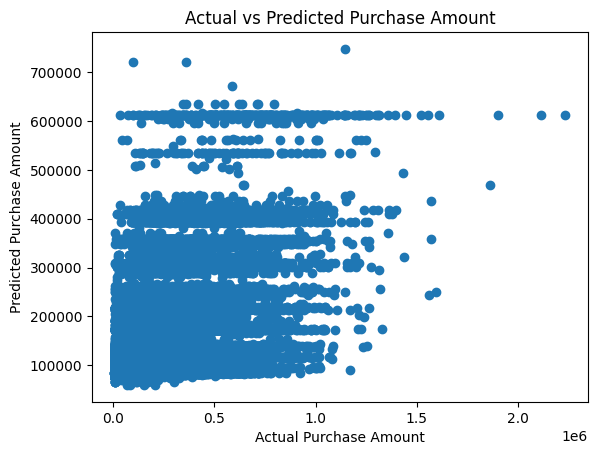

In [7]:
# 結果の可視化
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Purchase Amount")
plt.ylabel("Predicted Purchase Amount")
plt.title("Actual vs Predicted Purchase Amount")
plt.show()

In [8]:
import pandas as pd

# データの読み込み
transaction_history = pd.read_csv("../data/transaction_history.csv", dtype={"customer_id": str})

# データの確認
print(transaction_history.head())

  customer_id product_id purchase_date  purchase_amount  redeem_coupon  \
0    00023085   G03257PD     2020/3/13             7200           True   
1    00015469   CKZF21ZC     2023/3/29            15400          False   
2    00015482   7NSE0G0R    2023/12/26            15400          False   
3    00017107   WVCPYZBH     2021/2/19            17100          False   
4    00024156   OELTJ7E2     2020/10/8            24100           True   

   final_settlement_amount payment_method  purchase_channel  
0                   6200.0             現金               2.0  
1                      NaN            カード               2.0  
2                      NaN             現金               1.0  
3                      NaN            カード               2.0  
4                  23100.0            カード               1.0  


In [9]:
# Customer_IDごとに購入したProduct_IDを抽出
customer_products = (
    transaction_history.groupby("customer_id")["product_id"].apply(list).reset_index()
)
print(customer_products.head())

  customer_id  product_id
0    00010000  [AMHRGDP0]
1    00010001  [4ZIQTGYU]
2    00010002  [BV0C09UO]
3    00010003  [9HJSVDFB]
4    00010004  [AVLRU30G]


In [10]:
# product_masterの読み込み
product_master = pd.read_csv("../data/product_master.csv")

# データの確認
print(product_master.head())

  product_id            product_name  product_type     price departure_city  \
0   8RBQ8O3I   リラックスできるニューヨーク 6日間ツアー             3   72100.0             福岡   
1   ZFQK59UL          ドキドキの香港 5日間ツアー             3       NaN             京都   
2   5YH8O89R  ジャパンウィング航空 東京 → 高松 航空券             2    8500.0             東京   
3   MQTY8P6S           贅沢なドバイ 6日間ツアー             3  286100.0             東京   
4   1FKCUCHP           贅沢なドバイ 8日間ツアー             3  235000.0             京都   

  destination_city register_date  \
0           ニューヨーク     2023/8/28   
1               香港    2023/12/24   
2               高松      2024/9/5   
3              ドバイ    2024/10/29   
4              ドバイ     2023/5/13   

                                        description  
0   ニューヨークの魅力を存分に楽しめる6日間のツアー。リラックスできる体験を満喫し、心に残る旅を。  
1          香港の魅力を存分に楽しめる5日間のツアー。ドキドキな体験を満喫し、心に残る旅を。  
2  東京から高松へ、ジャパンウィング航空で快適な国内旅行を。お得な航空券で気軽に旅に出かけましょう。  
3           ドバイの魅力を存分に楽しめる6日間のツアー。贅沢な体験を満喫し、心に残る旅を。  
4           ドバイの魅力を存分に楽しめる8日間のツアー。贅沢な体

In [11]:
# product_idと渡航先の都市名をマージ
transaction_history = pd.merge(
    transaction_history,
    product_master[["product_id", "destination_city"]],
    on="product_id",
    how="left",
)

# customer_idごとに渡航先の都市名を抽出
customer_destinations = (
    transaction_history.groupby("customer_id")["destination_city"]
    .apply(list)
    .reset_index()
)
print(customer_destinations.head())

  customer_id destination_city
0    00010000             [パリ]
1    00010001             [松山]
2    00010002         [シンガポール]
3    00010003           [シドニー]
4    00010004            [ソウル]


In [12]:
# 渡航先の都市名をカウント
customer_destinations_exploded = customer_destinations.explode("destination_city")
customer_destination_counts = (
    customer_destinations_exploded.groupby(["customer_id", "destination_city"])
    .size()
    .unstack(fill_value=0)
)
print(customer_destination_counts.head())

destination_city  アブダビ  シドニー  シンガポール  ソウル  ドバイ  ニューヨーク  バンコク  パリ  ロンドン  ローマ  \
customer_id                                                                   
00010000             0     0       0    0    0       0     0   1     0    0   
00010001             0     0       0    0    0       0     0   0     0    0   
00010002             0     0       1    0    0       0     0   0     0    0   
00010003             0     1       0    0    0       0     0   0     0    0   
00010004             0     0       0    1    0       0     0   0     0    0   

destination_city  ...  旭川  松山  熊本  秋田  那覇  長崎  青森  静岡  香港  高松  
customer_id       ...                                          
00010000          ...   0   0   0   0   0   0   0   0   0   0  
00010001          ...   0   1   0   0   0   0   0   0   0   0  
00010002          ...   0   0   0   0   0   0   0   0   0   0  
00010003          ...   0   0   0   0   0   0   0   0   0   0  
00010004          ...   0   0   0   0   0   0   0   0   0   0 

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-meansクラスタリングの実行
kmeans = KMeans(n_clusters=5, random_state=42)
customer_clusters = kmeans.fit_predict(customer_destination_counts)

# クラスタリング結果の追加
customer_destination_counts["Cluster"] = customer_clusters
print(customer_destination_counts.head())

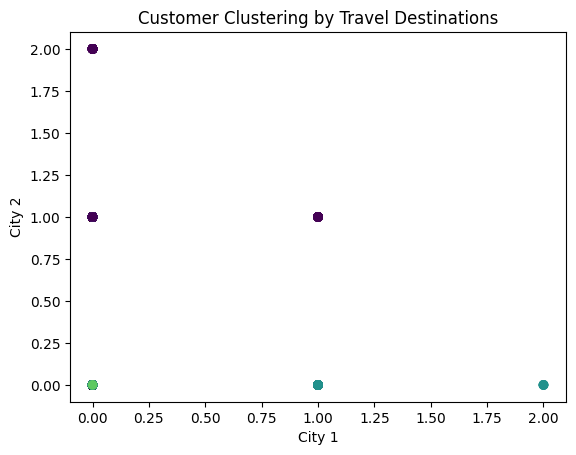

In [14]:
# クラスタリング結果の可視化
plt.scatter(
    customer_destination_counts.iloc[:, 0],
    customer_destination_counts.iloc[:, 1],
    c=customer_clusters,
    cmap="viridis",
)
plt.xlabel("City 1")
plt.ylabel("City 2")
plt.title("Customer Clustering by Travel Destinations")
plt.show()